In [2]:
import numpy as np
import pandas as pd
import os

In [3]:
import sys
print(sys.executable)

c:\Users\tommy\anaconda3\python.exe


In [ ]:

#getting all datasets into a dataframe
weather = pd.read_parquet("C:/Users/tommy/OneDrive/Documents/GitHub/data-science-capstone/changedData/cleaned_data/weather.parquet", engine="fastparquet")
weather
rtm = pd.read_parquet("C:/Users/tommy/OneDrive/Documents/GitHub/data-science-capstone/changedData/cleaned_data/rtm.parquet", engine="fastparquet")
rtm
load = pd.read_parquet("C:/Users/tommy/OneDrive/Documents/GitHub/data-science-capstone/changedData/cleaned_data/load.parquet", engine="fastparquet")
outage = pd.read_parquet("C:/Users/tommy/OneDrive/Documents/GitHub/data-science-capstone/changedData/cleaned_data/outage.parquet", engine="fastparquet")
dam = pd.read_parquet("C:/Users/tommy/OneDrive/Documents/GitHub/data-science-capstone/changedData/cleaned_data/dam.parquet", engine="fastparquet")

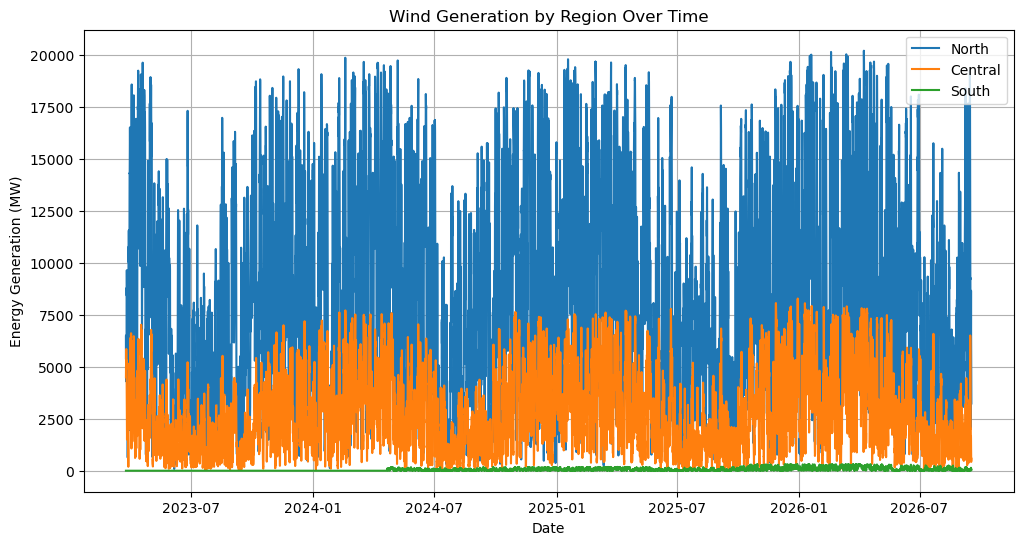

In [ ]:
import matplotlib.pyplot as plt
#wind generation plot 
plt.figure(figsize=(12,6))
plt.plot(weather["interval_start_utc"], weather["north_wind"], label="North")
plt.plot(weather["interval_start_utc"], weather["central_wind"], label="Central")
plt.plot(weather["interval_start_utc"], weather["south_wind"], label="South")
#plt.plot(winddf["interval_start_utc"], winddf["miso_wind"], label="MISO")

plt.xlabel("Date")
plt.ylabel("Energy Generation (MW)")
plt.title("Wind Generation by Region Over Time")
plt.legend()
plt.grid(True)
plt.show()

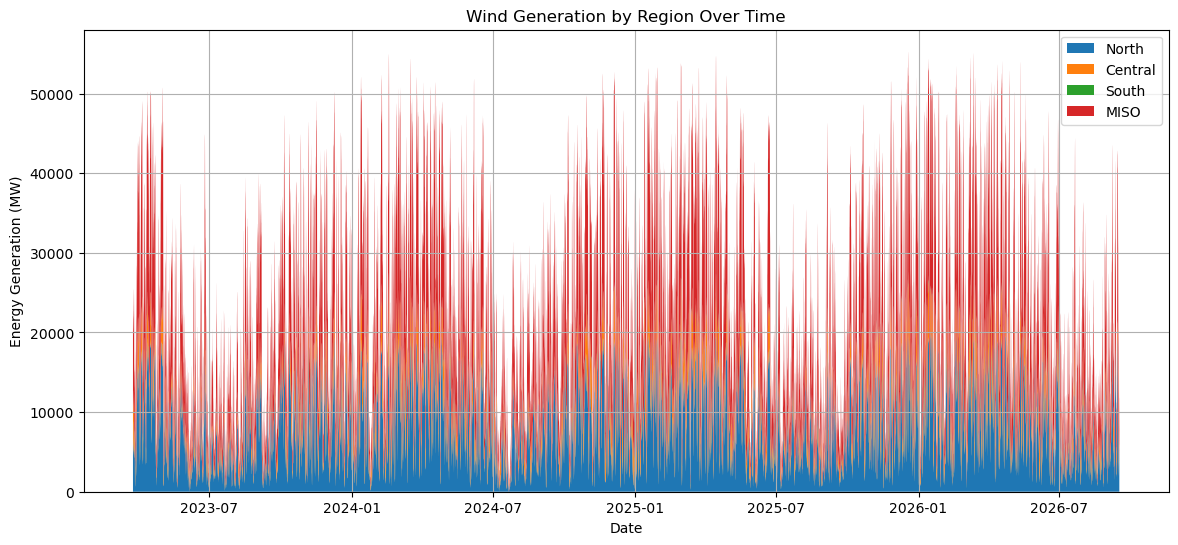

In [ ]:
plt.figure(figsize=(14, 6))

plt.stackplot(
    weather["interval_start_utc"],
    weather["north_wind"],
    weather["central_wind"],
    weather["south_wind"],
    weather["miso_wind"],
    labels=["North", "Central", "South", "MISO"]
)

plt.xlabel("Date")
plt.ylabel("Energy Generation (MW)")
plt.title("Wind Generation by Region Over Time")
plt.legend()
plt.grid(True)
plt.show()

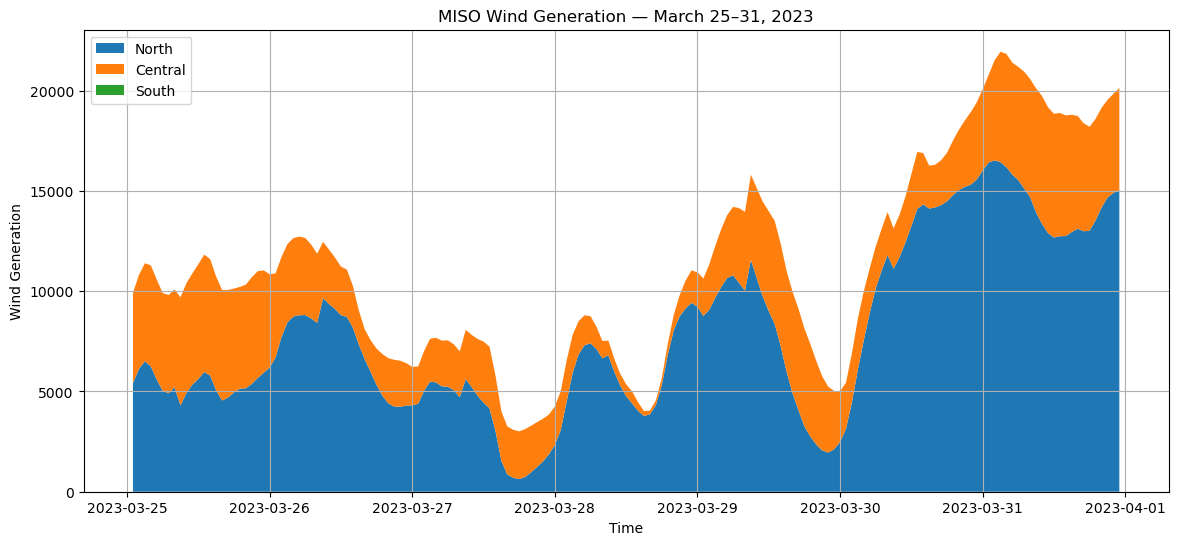

In [ ]:
#wind generation for about a week

week = weather[
    (weather["interval_start_utc"] >= "2023-03-25") &
    (weather["interval_start_utc"] < "2023-04-01")
]

plt.figure(figsize=(14, 6))

plt.stackplot(
    week["interval_start_utc"],
    week["north_wind"],
    week["central_wind"],
    week["south_wind"],
    labels=["North", "Central", "South"]
)

plt.xlabel("Time")
plt.ylabel("Wind Generation (MW)")
plt.title("MISO Wind Generation — March 25–31, 2023")
plt.legend(loc="upper left")
plt.grid(True)

plt.show()

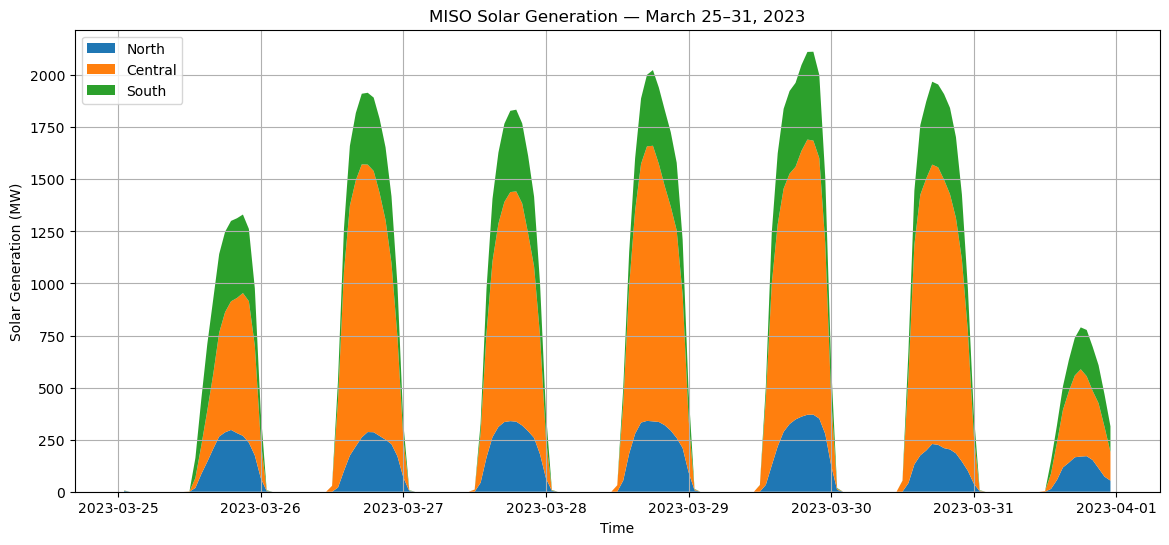

In [ ]:
#solar
week = weather[
    (weather["interval_start_utc"] >= "2023-03-25") &
    (weather["interval_start_utc"] < "2023-04-01")
]

plt.figure(figsize=(14, 6))

plt.stackplot(
    week["interval_start_utc"],
    week["north_solar"],
    week["central_solar"],
    week["south_solar"],
    labels=["North", "Central", "South"]
)

plt.xlabel("Time")
plt.ylabel("Solar Generation (MW)")
plt.title("MISO Solar Generation — March 25–31, 2023")
plt.legend(loc="upper left")
plt.grid(True)

plt.show()

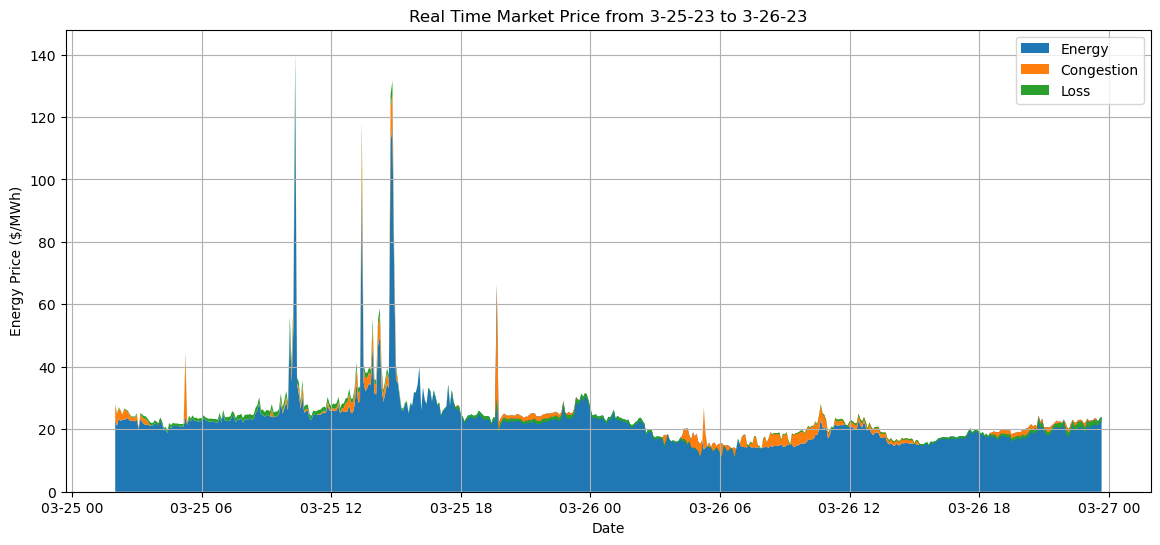

In [ ]:
#real time market for one day

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
week = rtm[
    (rtm["interval_end_utc"] >= "2023-03-25 02:00:00+00:00") &
    (rtm["interval_end_utc"] < "2023-03-26 23:45:00+00:00")
]

plt.stackplot(
    week["interval_end_utc"],
    week["energy"],
    week["congestion"],
    week["loss"],
    labels=["Energy", "Congestion", "Loss"]
)


plt.xlabel("Date")
plt.ylabel("Energy Price ($/MWh)")
plt.title("Market Price from 3-25-23 to 3-26-23")
plt.legend()
plt.grid(True)
plt.show()

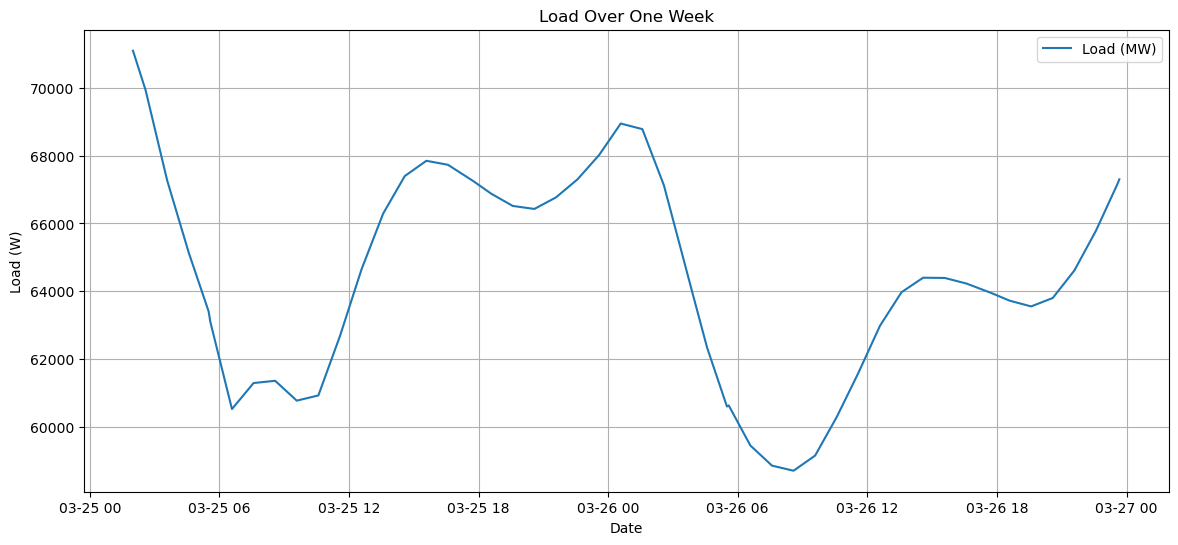

In [14]:
#load
load

plt.figure(figsize=(14, 6))

week = load[
    (load["interval_end_utc"] >= "2023-03-25 02:00:00+00:00") &
    (load["interval_end_utc"] < "2023-03-26 23:45:00+00:00")
]

plt.plot(
    week["interval_end_utc"],
    week["load_forecast"],
    label=["Load (MW)"]
)

plt.xlabel("Date")
plt.ylabel("Load (W)")
plt.title("Load Over One Week")
plt.legend()
plt.grid(True)
plt.show()

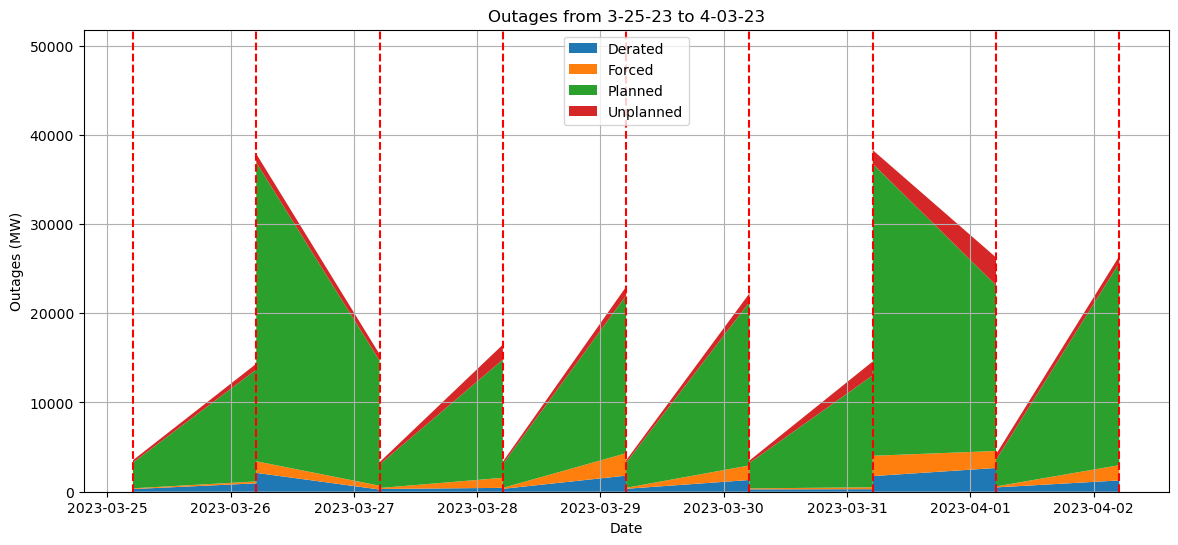

,interval_start_utc,interval_end_utc,publish_time_utc,region,derated_outages_mw,forced_outages_mw,planned_outages_mw,unplanned_outages_mw,year
2268,2023-03-24 05:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-21 05:00:00+00:00,Central,1619,1653,18499,40.0,2023
2269,2023-03-24 05:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-21 05:00:00+00:00,MISO,2946,2002,33775,2933.0,2023
2270,2023-03-24 05:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-21 05:00:00+00:00,North,374,135,2879,271.0,2023
2271,2023-03-24 05:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-21 05:00:00+00:00,South,953,214,12397,2622.0,2023
2272,2023-03-24 05:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-22 05:00:00+00:00,Central,1844,1951,18476,509.0,2023
...,...,...,...,...,...,...,...,...,...
2515,2023-04-01 05:00:00+00:00,2023-04-02 05:00:00+00:00,2023-03-27 05:00:00+00:00,Central,726,1490,22689,605.0,2023
2516,2023-04-01 05:00:00+00:00,2023-04-02 05:00:00+00:00,2023-03-27 05:00:00+00:00,MISO,2072,2311,41898,1528.0,2023
2517,2023-04-01 05:00:00+00:00,2023-04-02 05:00:00+00:00,2023-03-27 05:00:00+00:00,North,416,48,5054,266.0,2023
2518,2023-04-01 05:00:00+00:00,2023-04-02 05:00:00+00:00,2023-03-27 05:00:00+00:00,South,930,773,14155,657.0,2023


In [30]:
#outage
outage

plt.figure(figsize=(14, 6))
week = outage[
    (outage["interval_end_utc"] >= "2023-03-25 05:00:00+00:00") &
    (outage["interval_end_utc"] < "2023-04-03 05:00:00+00:00")
]

plt.stackplot(
    week["interval_end_utc"],
    week["derated_outages_mw"],
    week["forced_outages_mw"],
    week["planned_outages_mw"],
    week["unplanned_outages_mw"],
    labels=["Derated", "Forced", "Planned", "Unplanned"]
)

for day in pd.date_range("2023-03-25", "2023-04-02", freq="D", tz= "UTC"):
    day = day + pd.Timedelta(hours=5)
    plt.axvline(
        day,
        color="red",
        linestyle="--",
    )


plt.xlabel("Date")
plt.ylabel("Outages (MW)")
plt.title("Outages from 3-25-23 to 4-03-23")
plt.legend()
plt.grid(True)
plt.show()
week